##Q5
##Part A)
You are tasked with designing an AI system for autonomous driving that
must:

• Detect objects (cars, pedestrians, traffic lights)

• Understand road regions (lanes, sidewalks)

• Explain why image classification models (CNNs) alone are
insufficient for this task.

Your answer must include:

a. Difference between classification vs localization

b. Need for spatial understanding

c. Limitations in real-world driving scenarios

##Answer:

An AI system for autonomous driving requires more than just image classification. While Convolutional Neural Networks (CNNs) are excellent at classifying objects, they fall short in several critical areas for this complex task.

### a. Difference between Classification vs. Localization

*   **Image Classification:** This task involves assigning a single label to an entire image, indicating the presence of a particular object or scene. For example, a classifier might tell you 'this image contains a car'. It answers the question 'What is in this image?'

*   **Object Localization:** This task goes beyond classification by not only identifying what objects are in an image but also where they are. It involves drawing bounding boxes around each detected object. For autonomous driving, knowing *where* a car, pedestrian, or traffic light is located in the scene (its position and size) is crucial for decision-making.

*   **Object Detection:** This is a combination of both classification and localization. It identifies multiple objects within an image and provides their bounding box coordinates and class labels.

CNNs primarily perform classification. While they can be adapted for localization through techniques like object detection architectures (e.g., YOLO, Faster R-CNN), a pure classification CNN doesn't provide the spatial information needed for driving.

### b. Need for Spatial Understanding

Autonomous driving demands a deep spatial understanding of the environment. This includes:

*   **Precise Object Location:** Knowing the exact position and distance of other vehicles, pedestrians, and obstacles is vital for path planning, collision avoidance, and maintaining safe distances.

*   **Depth Perception:** A 2D classification output doesn't convey depth. Autonomous vehicles need to understand the 3D world to judge distances and relative speeds accurately.

*   **Contextual Relationships:** Understanding how objects relate to each other spatially (e.g., a pedestrian *on* a sidewalk, a car *in* a lane) is essential. A classification model might identify 'car' and 'road', but not that *this specific car* is *on this specific road segment* and *moving towards the intersection*.

*   **Road Region Understanding:** Identifying and segmenting road regions like lanes, sidewalks, crosswalks, and buildable areas is fundamental for navigation. This is a pixel-level classification task (semantic segmentation) that goes beyond broad image classification.

### c. Limitations in Real-World Driving Scenarios

Pure image classification models face significant limitations in real-world autonomous driving:

*   **Occlusion:** Objects are often partially hidden by other objects (e.g., a car behind another car). A classifier might struggle to identify partially occluded objects, whereas localization models can still infer their presence and approximate location.

*   **Varying Lighting and Weather Conditions:** Classifiers trained on ideal conditions may fail in low light, heavy rain, fog, or direct sunlight. Autonomous systems need robustness to these variations, which often requires advanced data augmentation, sensor fusion, and more complex models.

*   **Dynamic Environments:** Driving environments are constantly changing. A car suddenly braking, a pedestrian stepping onto the road, or a traffic light changing requires real-time detection and prediction, which simple classification cannot provide.

*   **Safety Criticality:** Misclassifications or missed detections in autonomous driving can have catastrophic consequences. A classification model might correctly identify 99% of cars, but the 1% it misses could lead to an accident. Localization and robust object detection with high recall are paramount.

*   **Decision Making:** Autonomous vehicles don't just 'see'; they must 'understand' and 'act'. This requires taking the output of perception (object detection, spatial understanding) and feeding it into planning and control modules. A classification label alone offers insufficient input for these complex decision-making processes.

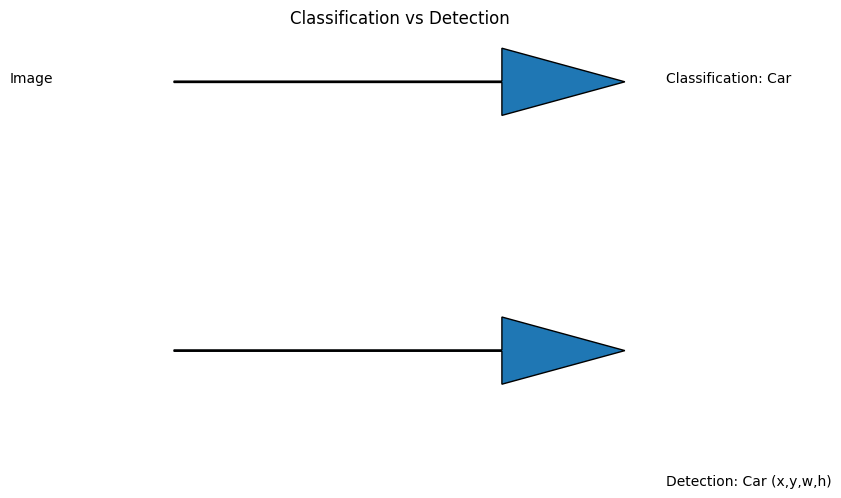

In [2]:

import matplotlib.pyplot as plt

plt.figure()
plt.text(0.1,0.6,"Image")
plt.text(0.5,0.6,"Classification: Car")
plt.text(0.5,0.3,"Detection: Car (x,y,w,h)")

plt.arrow(0.2,0.6,0.2,0, head_width=0.05)
plt.arrow(0.2,0.4,0.2,0, head_width=0.05)

plt.axis('off')
plt.title("Classification vs Detection")
plt.show()

##Part B)

Compare the following approaches:

• Object Detection (e.g., YOLO)

• Semantic Segmentation (e.g., U-Net)

Your comparison must include:

a. Output representation differences

b. Use cases in autonomous driving

c. Computational trade-offs

d. Accuracy vs speed considerations

##Answer:

For autonomous driving, both Object Detection and Semantic Segmentation are crucial perception tasks, but they provide different levels of detail and serve distinct purposes.

### a. Output Representation Differences

*   **Object Detection (e.g., YOLO, Faster R-CNN):**
    *   **Output:** Generates bounding boxes around detected objects, along with a class label and a confidence score for each box. The output is a list of (x, y, width, height, class, confidence) tuples.
    *   **Granularity:** Object-level. It tells you *what* an object is and *where* it is located (its rectangular extent).
    *   **Example:** For a car, it draws a box around the entire car and labels it 'car'. It does not differentiate between the car's body, windows, or wheels at a pixel level.

*   **Semantic Segmentation (e.g., U-Net, DeepLab):**
    *   **Output:** Assigns a class label to *every single pixel* in the image. The output is a pixel-wise mask where each pixel is colored according to its semantic class (e.g., road, car, sky, pedestrian).
    *   **Granularity:** Pixel-level. It tells you *what* each pixel belongs to.
    *   **Example:** For a car, it identifies every pixel that constitutes the car as 'car', every pixel that is the road as 'road', and so on. It provides precise boundaries of objects and regions.

### b. Use Cases in Autonomous Driving

*   **Object Detection:**
    *   **Primary Use:** Identifying and locating dynamic objects in the scene that require immediate attention and interaction (cars, pedestrians, cyclists, traffic lights, signs).
    *   **Decision Making:** Essential for collision avoidance, path planning (knowing where other vehicles are to predict their trajectory), and responding to traffic signals.
    *   **Examples:** Detecting a pedestrian crossing the road, identifying a car in an adjacent lane, recognizing a stop sign.

*   **Semantic Segmentation:**
    *   **Primary Use:** Understanding the drivable surface, identifying road boundaries, lanes, sidewalks, and other static environmental elements. It provides a rich contextual understanding of the scene.
    *   **Decision Making:** Critical for continuous path planning, understanding safe drivable areas, distinguishing between road and non-road regions, and ensuring the vehicle stays within its lane.
    *   **Examples:** Differentiating between the road and the sidewalk, identifying painted lane markings, recognizing buildable areas, detecting puddles or obstacles *on* the road surface at a fine-grained level.

### c. Computational Trade-offs

*   **Object Detection:**
    *   **Complexity:** Generally less computationally intensive than semantic segmentation, especially for single-shot detectors like YOLO, because it predicts a limited number of bounding boxes rather than classifying every pixel.
    *   **Memory:** Requires less memory compared to semantic segmentation as it doesn't need to store a dense pixel-wise prediction map.
    *   **Training Data:** Bounding box annotations are less labor-intensive to create than pixel-wise masks.

*   **Semantic Segmentation:**
    *   **Complexity:** More computationally demanding as it performs a pixel-level classification for the entire image. This typically involves larger models or more complex architectures.
    *   **Memory:** Requires more memory, especially for high-resolution images, due to the need to store and process dense pixel predictions.
    *   **Training Data:** Pixel-wise annotations (masks) are significantly more labor-intensive and expensive to create, requiring precise labeling of every object and region.

### d. Accuracy vs. Speed Considerations

*   **Object Detection:**
    *   **Speed:** Modern object detectors (especially one-stage detectors like YOLO, SSD) are optimized for real-time performance, achieving very high frame rates suitable for autonomous driving's strict latency requirements.
    *   **Accuracy:** Typically measures accuracy based on metrics like Mean Average Precision (mAP), which evaluates both correct classification and accurate localization of bounding boxes. While highly accurate for object presence and coarse location, it lacks fine-grained boundary precision.
    *   **Balance:** There's a good balance of speed and sufficient accuracy for many dynamic object interactions.

*   **Semantic Segmentation:**
    *   **Speed:** Historically slower than object detection due to its dense prediction nature. However, recent advancements have led to real-time semantic segmentation models, though often at the cost of some accuracy or requiring specialized hardware.
    *   **Accuracy:** Measures accuracy using metrics like Mean Intersection Over Union (mIoU), which evaluates how well the predicted pixel masks overlap with ground truth masks. It offers superior spatial precision and boundary accuracy.
    *   **Balance:** Achieving high accuracy at pixel level, especially for fine details and boundaries, often comes with a higher computational cost, potentially impacting real-time capability without significant optimization or powerful hardware.

**Conclusion:** Both object detection and semantic segmentation are indispensable for a robust autonomous driving system. They are often used in conjunction, with object detection handling dynamic, interactive elements, and semantic segmentation providing a detailed understanding of the static environment and precise object boundaries.

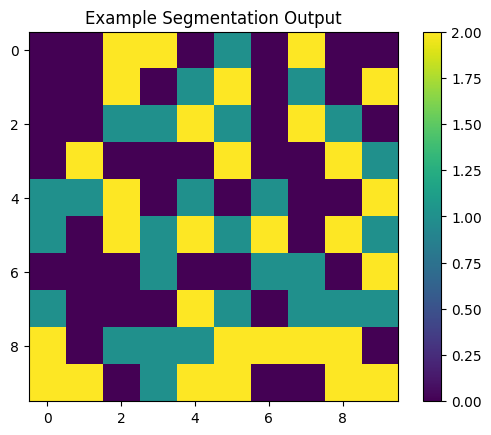

In [3]:

import numpy as np
import matplotlib.pyplot as plt

seg_map = np.random.randint(0, 3, (10,10))

plt.figure()
plt.imshow(seg_map)
plt.colorbar()
plt.title("Example Segmentation Output")
plt.show()

##Part C)

Design a complete perception pipeline for the autonomous driving system.

Your design must include:

a. Input processing (camera frames)

b. Detection module (bounding boxes)

c. Segmentation module (pixel-wise understanding)

d. Integration of both outputs

Additionally:

e. Suggest one enhancement using modern architectures (e.g.,
Vision Transformers or hybrid CNN-Transformer models)

##Answer:

A robust perception pipeline is the foundation of any autonomous driving system. It takes raw sensor data and transforms it into actionable information for planning and control modules.

Here's a design for such a pipeline:

### Autonomous Driving Perception Pipeline Design

#### a. Input Processing (Camera Frames)

*   **Sensors:** Primary input will be high-resolution camera feeds (e.g., front, rear, side-view cameras). Optionally, inputs from LiDAR, Radar, and Ultrasonic sensors can be fused at a later stage, but for this design, we'll focus on camera frames.
*   **Preprocessing:**
    *   **Calibration:** Apply intrinsic and extrinsic camera calibration to correct for lens distortions and project 2D image coordinates to 3D world coordinates.
    *   **Normalization/Augmentation:** Normalize pixel values (e.g., to [0, 1] or [-1, 1]). Real-time data augmentation (e.g., color jitter, random flips, cropping) can be applied during training for robustness, but minimal processing for inference to maintain speed.
    *   **Synchronization:** If multiple cameras are used, ensure frames are synchronized to provide a coherent view of the environment at any given timestamp.
    *   **Region of Interest (ROI) Selection (Optional but beneficial):** Focus computation on relevant areas of the image (e.g., road ahead, adjacent lanes) to improve efficiency.

#### b. Detection Module (Bounding Boxes)

*   **Purpose:** Identify and localize dynamic objects of interest (cars, trucks, pedestrians, cyclists, traffic lights, traffic signs, etc.) in the processed camera frames.
*   **Architecture:** Utilize a real-time, high-performance object detection model. Examples include:
    *   **YOLO (You Only Look Once) series (e.g., YOLOv7, YOLOv8):** Known for its balance of speed and accuracy, making it suitable for real-time applications.
    *   **SSD (Single Shot Detector):** Another efficient option for real-time detection.
    *   **EfficientDet:** Designed for multi-scale feature fusion and efficient performance.
*   **Output:** For each detected object:
    *   **Bounding Box Coordinates:** (x, y, width, height) indicating the object's location and size.
    *   **Class Label:** E.g., 'car', 'pedestrian', 'traffic light'.
    *   **Confidence Score:** Probability that the detection is correct.
    *   **(Optional) Depth Estimation:** Integrate monocular or stereo depth estimation to provide rough 3D locations for detected objects.

#### c. Segmentation Module (Pixel-wise Understanding)

*   **Purpose:** Provide a detailed pixel-level understanding of the scene, crucial for identifying drivable areas, lanes, sidewalks, and precise object boundaries.
*   **Architecture:** Employ a semantic segmentation model capable of real-time inference. Examples include:
    *   **U-Net / PSPNet / DeepLabV3+:** Classic and highly effective architectures for pixel-level classification.
    *   **BiSeNet / SwiftNet:** Designed for high-speed semantic segmentation on edge devices.
*   **Output:** A segmentation mask (same resolution as input, or downsampled then upsampled) where each pixel is assigned a semantic class label (e.g., 'road', 'lane marking', 'sidewalk', 'car', 'sky', 'building', 'vegetation'). This provides precise boundaries and contextual information.

#### d. Integration of Both Outputs

*   **Fusion Layer:** A dedicated module to combine the discrete object-level information from the Detection Module with the pixel-level contextual understanding from the Segmentation Module.
*   **Steps:**
    1.  **Overlay:** Overlay the detected bounding boxes onto the semantic segmentation mask.
    2.  **Refinement:** Use the segmentation mask to refine the boundaries of detected objects. For example, if a bounding box partially covers a 'pedestrian' region and a 'road' region, the segmentation can help accurately delineate the pedestrian's shape.
    3.  **Contextual Association:** Associate detected objects with their semantic surroundings. E.g., confirm a 'pedestrian' detection is *on* a 'sidewalk' or *crossing* the 'road' based on segmentation labels within and around the bounding box.
    4.  **Scene Understanding Graph:** Construct a higher-level scene representation, potentially a graph where nodes are objects and semantic regions, and edges represent spatial relationships (e.g., 'car A is in front of car B', 'pedestrian is on crosswalk').
    5.  **Prioritization:** Assign confidence levels and prioritize critical information (e.g., dynamic objects in immediate path, traffic lights) for downstream planning.
*   **Output to Planning/Control:** A consolidated scene understanding that includes:
    *   Precise locations and identities of all critical objects.
    *   Drivable path, lane boundaries, and non-drivable regions.
    *   Semantic context for decision-making (e.g., a traffic light is red, a pedestrian is crossing the crosswalk, an obstacle is detected in the drivable path).

#### e. Suggest one enhancement using modern architectures (e.g., Vision Transformers or hybrid CNN-Transformer models)

*   **Multi-Modal Fusion with Transformers:** Integrate Vision Transformers (ViT) or hybrid CNN-Transformer architectures (e.g., Swin Transformers, DETR) within a multi-modal fusion framework. Instead of processing camera frames in isolation, extend the pipeline to incorporate data from other sensors (LiDAR, Radar) and fuse them at an early or intermediate stage using Transformer-based encoders.
    *   **How it works:**
        *   Each sensor stream (camera, LiDAR point clouds, Radar scans) is processed by its own specialized encoder (CNN for images, PointNet-like for LiDAR, etc.).
        *   The encoded features from different modalities are then fed into a Transformer encoder. The self-attention mechanism of the Transformer can effectively learn complex spatial and temporal relationships *across* different sensor modalities, creating a rich, fused representation of the scene.
        *   This fused representation can then be fed to detection and segmentation heads to produce more robust and accurate predictions, especially in challenging conditions where one sensor might fail (e.g., camera in fog, LiDAR in heavy rain).
    *   **Benefits:** Improved robustness, better contextual understanding, enhanced ability to handle occlusions and varying environmental conditions, and potentially better long-range perception due to the global receptive field of Transformers.

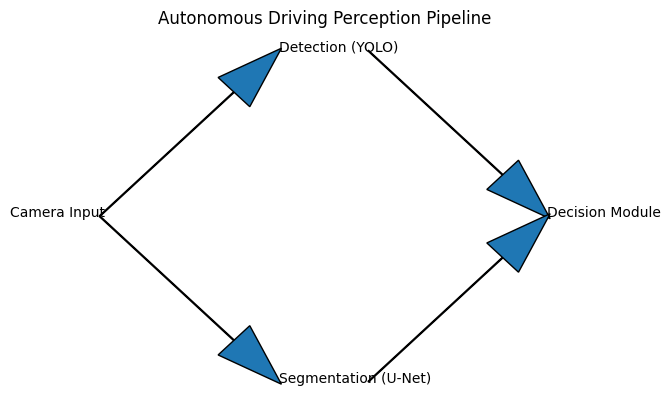

In [4]:

import matplotlib.pyplot as plt

plt.figure()

plt.text(0.1,0.5,"Camera Input")
plt.text(0.4,0.7,"Detection (YOLO)")
plt.text(0.4,0.3,"Segmentation (U-Net)")
plt.text(0.7,0.5,"Decision Module")

plt.arrow(0.2,0.5,0.15,0.15, head_width=0.05)
plt.arrow(0.2,0.5,0.15,-0.15, head_width=0.05)
plt.arrow(0.5,0.7,0.15,-0.15, head_width=0.05)
plt.arrow(0.5,0.3,0.15,0.15, head_width=0.05)

plt.axis('off')
plt.title("Autonomous Driving Perception Pipeline")
plt.show()
